# Linear Bivariate BMM with SAMBA toy models : step mixing

The best way to learn Taweret is to use it. You can run, modify and experiment with this notebook [on GitHub Codespaces](https://github.com/bandframework/Taweret).

This notebook shows how to use the Bayesian model mixing package **Taweret** for a toy problem. 

Author : Dan Liyanage 

Date : 11/10/2022

More about SAMBA toy models can be found in [Uncertainties here, there, and everywhere: interpolating between small- and large-g expansions using Bayesian Model Mixing](https://arxiv.org/abs/2206.04116)



In [9]:
%load_ext autoreload
%autoreload 2

import sys
import os

# You will have to change the following imports depending on where you have 
# the packages installed

# ! pip install Taweret    # if using Colab, uncomment to install

cwd = os.getcwd()

# Get the first part of this path and append to the sys.path
tw_path = cwd.split("Taweret/")[0] + "Taweret"
samba_path = tw_path + "/subpackages/SAMBA"
sys.path.append(tw_path)
sys.path.append(samba_path)

# For plotting
import matplotlib.pyplot as plt

! pip install seaborn    # comment if installed
! pip install ptemcee    # comment if installed

import seaborn as sns
sns.set_context('poster')
# To define priors. (uncoment if not using default priors)
# ! pip install bilby    # uncomment if not already installed
import bilby

# For other operations
import numpy as np

## 1. Get toy models and the pseudo-experimental data

In [10]:
# Toy models from SAMBA
sys.path.append('../../../src')
from Taweret.models import samba_models as toy_models

m1 = toy_models.Loworder(2, 'uninformative')
m2 = toy_models.Highorder(2, 'uninformative')
truth = toy_models.TrueModel()
exp = toy_models.Data()

In [11]:
g = np.linspace(0.1, 0.6, 10)
plot_g = np.linspace(0.01,1,100)
m1_prediction = m1.evaluate(plot_g)
m2_prediction = m2.evaluate(plot_g)
true_output = truth.evaluate(plot_g)
exp_data= exp.evaluate(g,error = 0.01)

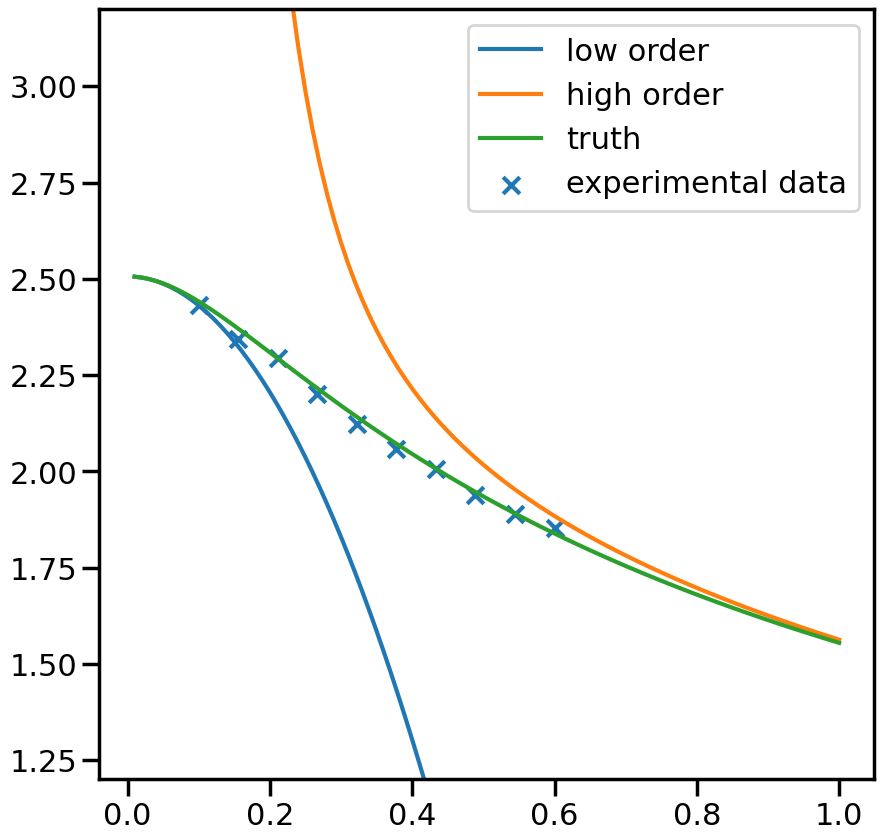

In [12]:

fig, ax_f = plt.subplots(figsize=(10,10))
ax_f.plot(plot_g, m1_prediction[0].flatten(), label='low order')
ax_f.plot(plot_g, m2_prediction[0].flatten(), label='high order')
ax_f.plot(plot_g, true_output[0], label='truth')
ax_f.scatter(g,exp_data[0], marker='x', label='experimental data')
ax_f.set_ylim(1.2,3.2)
ax_f.legend()

##  2. Choose a Mixing method

In [13]:
from Taweret.core.base_model import BaseModel
isinstance(m1, BaseModel)

True

In [14]:
# Mixing method
from Taweret.mix.bivariate_linear import BivariateLinear as BL

models= {'low_order':m1,'high_order':m2}
mix_model = BL(models_dic=models, method='step')

step mixing function has 1                   free parameter(s)
To change the prior use `set_prior` method


In [15]:
#uncoment to change the prior from the default
priors = bilby.core.prior.PriorDict()
priors['step_0'] = bilby.core.prior.Uniform(0.2, 0.8, name="step_0")
mix_model.set_prior(priors)

{'step_0': Uniform(minimum=0.2, maximum=0.8, name='step_0', latex_label='step_0', unit=None, boundary=None)}

## 3. Train to find posterior

In [16]:
y_exp = np.array(exp_data[0]).astype(np.float64)
y_err = np.array(exp_data[1]).astype(np.float64)

# The parameters are set to minimum values for computational ease.
# You should increase the ntemps, nwalkers and nsamples and see
# if your results are changing. If so keep increasing them
# until convergence of results.
import time
# initial positions because the sampler cannot get out of NaNs otherwise
nwalkers = 26  # number of walkers to use
ndim = 1         # step function number of params
ntemps = 5

# # guess for starting positions
# p0 = 1.0 + 0.01 * np.random.randn(ntemps, nwalkers, ndim)

kwargs_for_sampler = {'sampler': 'ptemcee',
                    'ntemps': ntemps,
                    'nwalkers': nwalkers,
                    'Tmax': 100,
                    'burn_in_fixed_discard': 50,
                    'nsamples': 2000,
                    'threads': 6,
                    'verbose':False}

result = mix_model.train(x_exp=g, y_exp=y_exp, y_err=y_err, outdir=f"outdir/samba_bivariate_{int(time.time())}" ,label='step_mix',
                          kwargs_for_sampler=kwargs_for_sampler)

TypeError: BivariateLinear.train() got an unexpected keyword argument 'plot'

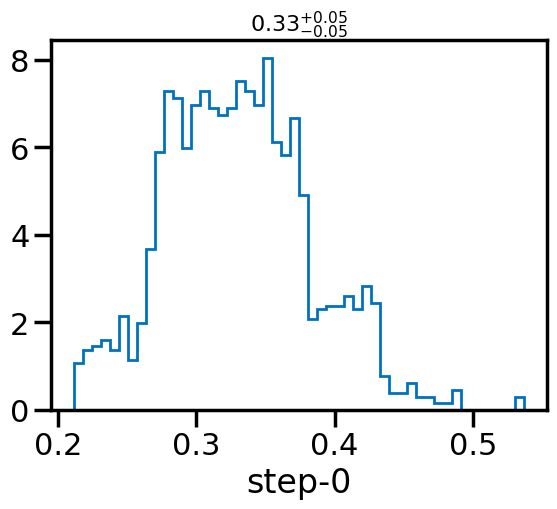

In [18]:
# Posterior of the mixing parameters. 
result.plot_corner()

## 4. Predictions

In [19]:
_,mean_prior,CI_prior, _ = mix_model.prior_predict(plot_g, CI=[5,20,80,95])
_,mean,CI, _ = mix_model.predict(plot_g, CI=[5,20,80,95])

(10000, 1)
using provided samples instead of posterior


In [20]:
per5, per20, per80, per95 = CI
prior5, prior20, prior80, prior95 = CI_prior

In [21]:
# Map value prediction for the step mixing function parameter
map_prediction = mix_model.evaluate(mix_model.map, plot_g)

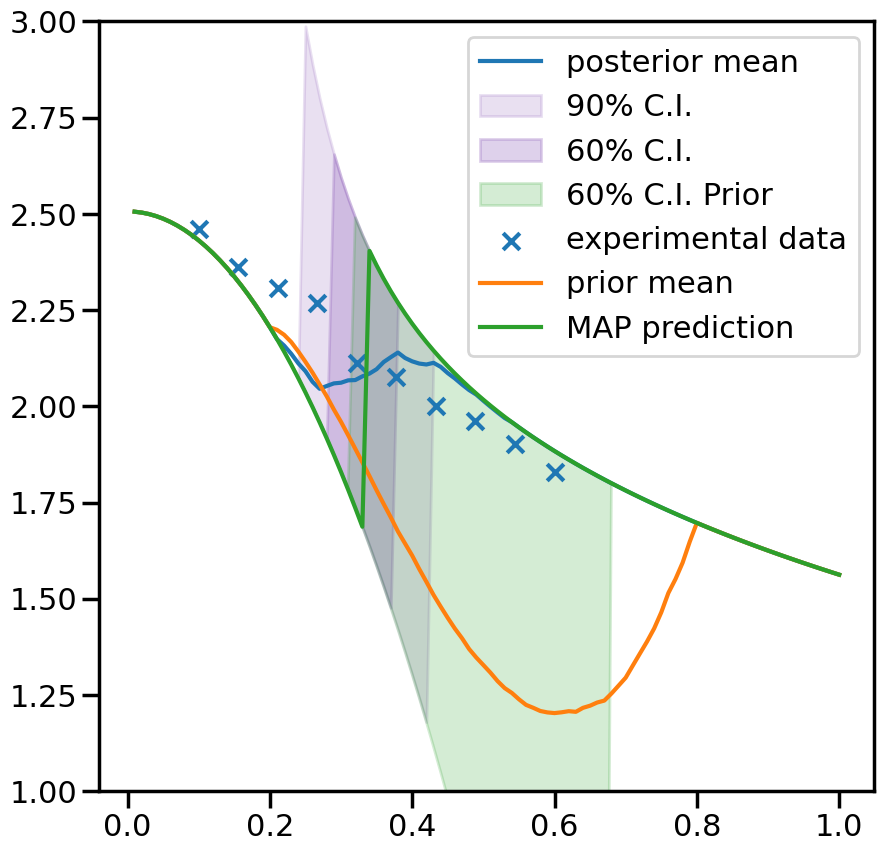

In [22]:
%matplotlib inline
sns.set_context('poster')
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(plot_g, mean.flatten(), label='posterior mean')
ax.fill_between(plot_g,per5.flatten(),per95.flatten(),color=sns.color_palette()[4], alpha=0.2, label='90% C.I.')
ax.fill_between(plot_g,per20.flatten(),per80.flatten(), color=sns.color_palette()[4], alpha=0.3, label='60% C.I.')
ax.fill_between(plot_g,prior20.flatten(),prior80.flatten(),color=sns.color_palette()[2], alpha=0.2, label='60% C.I. Prior')
ax.scatter(g,exp_data[0], marker='x', label='experimental data')
ax.plot(plot_g, mean_prior.flatten(), label='prior mean')
ax.plot(plot_g, map_prediction.flatten(), label='MAP prediction')
ax.set_ybound(1,3)
ax.legend()